In [2]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../..')
    import pySIMsalabim as sim
from pySIMsalabim.aux_funcs import DRT as drt
from pySIMsalabim.experiments.impedance import *
import pandas as pd


## Overview 

The purpose of this notebook is to examine whether DRT picks up on the same effects as Impedance Spectroscopy

In [5]:
# Read in both the impedance data and the DRT data
drt_models = pd.read_json('drt_models.json')
impedance = pd.read_csv('freqZ.dat', sep=r'\s+')

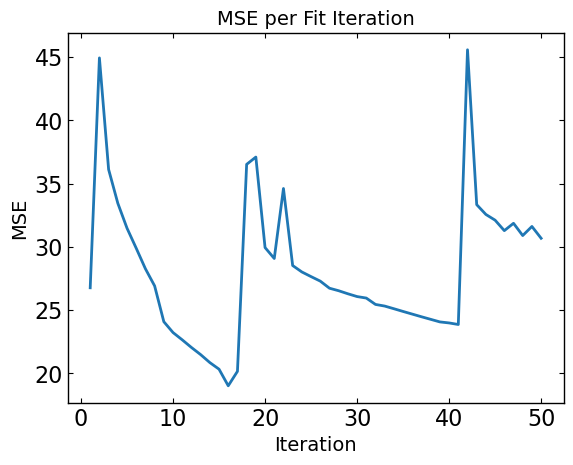

In [12]:
# Plot the MSE 
MSE = [drt_models[iteration]["MSE"] for iteration in drt_models.keys()]
drt.plot_MSE(MSE)

It's clear from the above graph that running DRT from the first index just after the perturbation is not suitable. I suspect we may have to resort to manual tuning here.

### Manually tune the current we pass to the DRT function

In [ ]:
tj_data = pd.read_csv('tj.dat', sep=r'\s+')

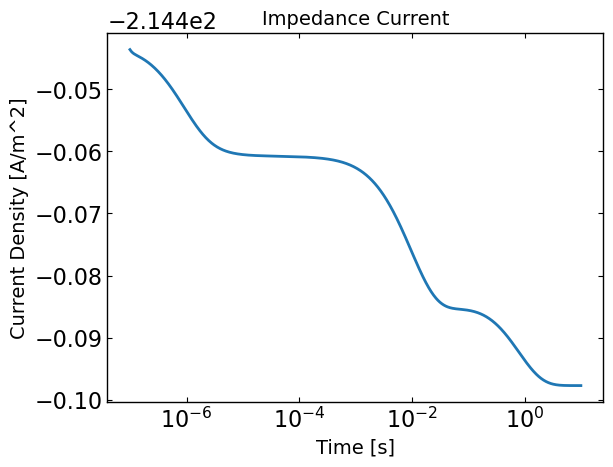

In [26]:
# Define the neccessary columns for analysis 
start_index = 55
end_index = -1

time = np.array(tj_data['t'])[start_index:end_index]
current = np.array(tj_data['Jext'])[start_index:end_index]

plt.plot(time, current)
plt.xlabel("Time [s]")
plt.ylabel("Current Density [A/m^2]")
plt.title("Impedance Current")
plt.xscale('log')

In [28]:
fits = drt.checkerboard_fit(time, current)

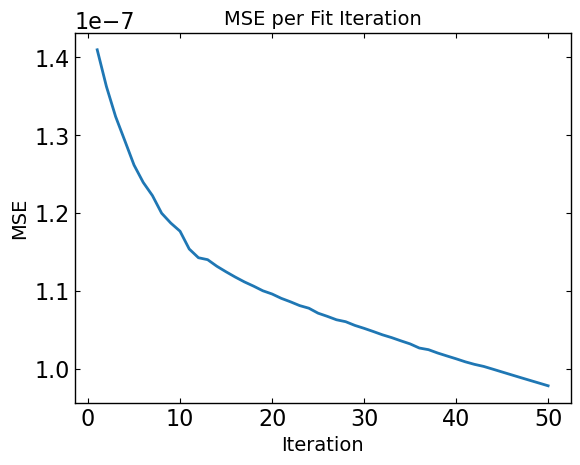

In [ ]:
# Check the MSE for these new fits 
drt.plot_MSE(fits)

As we can see, the MSE is significantly better if we zoom in on the signal. This unfortunately does mean running this just from the command line is going to be difficult to do. 

One potential, though potentially slow, automated manner of finding this point is to simply modify the starting index until we see a significant drop in fit error, taking that to be the effective drop in signal. Either that, or we first fit a single lifetime to get the initial decay, and then use DRT on the more complex signal after that

### Plot the modified DRT

In [38]:
# Get the fit round iteration 20, just after the most significant reduction in fit error
fit = fits[0]

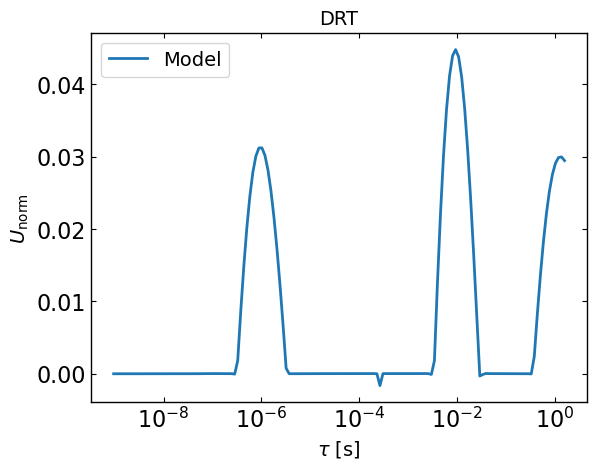

In [46]:
fit.plot_U(normalised=True)

In [ ]:
# Now try locating the lifetimes 
from scipy.signal import find_peaks

In [50]:
peaks = find_peaks(fit.U_norm, height=0.02)
peaks[0]

array([ 49, 113, 148])

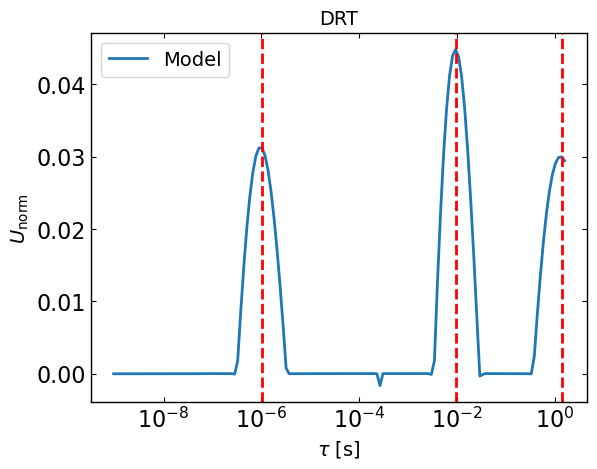

In [53]:
ax = fit.plot_U(normalised=True, return_ax=True)
for peak_index in peaks[0]:
    ax.axvline(fit.tau[peak_index], color='red', linestyle='--')

In [54]:
# Convert those lifetimes into frequencies 
peak_lifetimes = np.array([fit.tau[peak_index] for peak_index in peaks[0]])
peak_frequencies = np.array([1/(2*np.pi*lifetime) for lifetime in peak_lifetimes])
peak_frequencies

array([1.54801689e+05, 1.69635603e+01, 1.15811194e-01])

## Test to see if we can remove the initial step by fitting a single lifetime

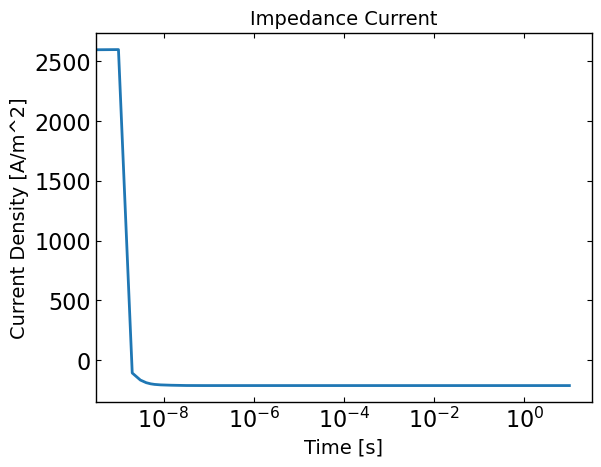

In [55]:
# Define the neccessary columns for analysis 
start_index = 0
end_index = -1

time = np.array(tj_data['t'])[start_index:end_index]
current = np.array(tj_data['Jext'])[start_index:end_index]

plt.plot(time, current)
plt.xlabel("Time [s]")
plt.ylabel("Current Density [A/m^2]")
plt.title("Impedance Current")
plt.xscale('log')

In [ ]:
# Apply DRT linear fit 
fit = drt.linear_fit(time, current, bounds=(0, np.inf), scaling=True)

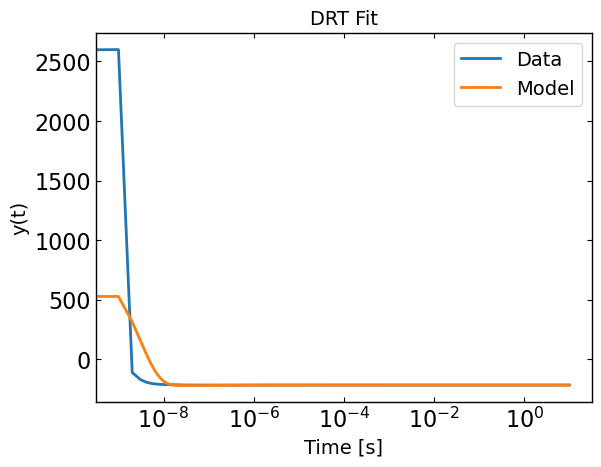

In [63]:
fit.plot_y_model(time, current)

It's clear the fit struggles with a peak so large and, I suspect, with a cutoff so short. In fairness, if we're only interested in the lower frequency peak at around 100kHz or 10^-6 seconds, we can just set the start time to cut off values we're less interested in

In [68]:
start_time = 1E-7 #s
filter = np.where(time>start_time)
time = time[filter]
current = current[filter]

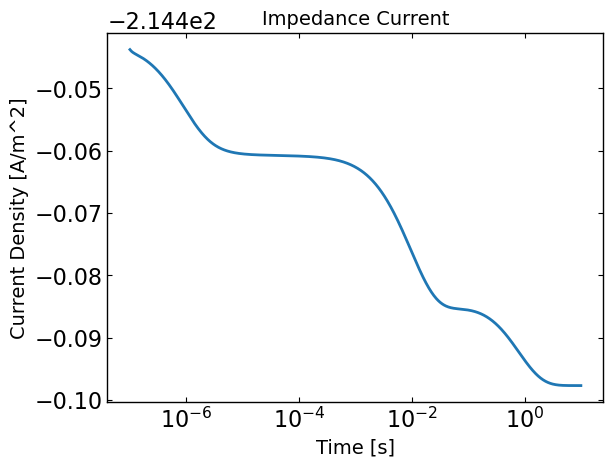

In [69]:
plt.plot(time, current)
plt.xlabel("Time [s]")
plt.ylabel("Current Density [A/m^2]")
plt.title("Impedance Current")
plt.xscale('log')

Setting the start time to 1E-7 here works perfectly. This may just need to be a step that is verified by visual inspection on a dataset to begin with

In [70]:
fits = drt.checkerboard_fit(time, current)

In [72]:
fit = fits[0]

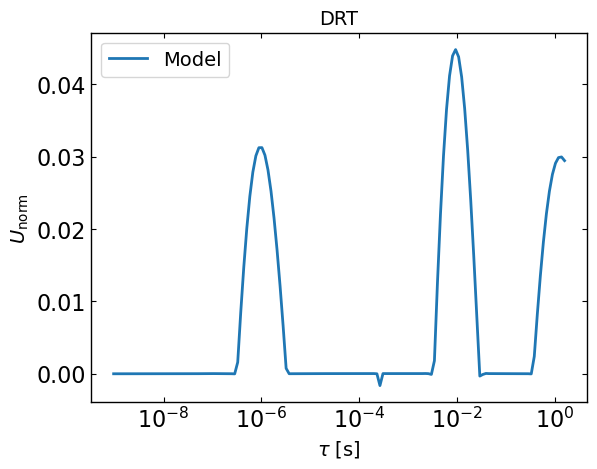

In [71]:
fits[0].plot_U(normalised=True)

In [82]:
maximum_peak_height = fit.U_norm.max()
height_threshold = 0.01*maximum_peak_height
peaks = find_peaks(fit.U_norm, height=height_threshold)
print(f"Height threshold {height_threshold}: {peaks[0]}")

Height threshold 0.00044795526432231544: [ 49 113 148]


### Suggested method for mass analsysis 
1. Curtail time to start at 1E-7, which should leave plenty of space for the 1E-6 peak
2. Set the height threshold for peak finding to be 1% of the greatest peak. Because most of the signal is zero, this should allow for all significant peaks while filtering out most peaks from distortion.